## Replication of Bursztyn et al. (2022): Opinions as Facts

**The paper:**
The goal of this paper is to ...

**Disclaimer:**
In this notebook, I replicate the key results from Bursztyn et al. (2022). In my attempt to use the scripts included in the original replication package provided by the authors, I often run into package compatibility issues which prevented the execution of the code. The scripts incorporated in this notebook are adapted accordingly, in ways that ae not expected to affect the essence and results of the original code. The changes made are mentioned in the README file.

This notebook follows the logic of the paper and does not cover any results included in the Supplementary material provided by the authors. 



### *Trust in opinion shows*

In this section, the authors provide evidence that people turn to opinion shows over straight news to learn about objective facts. 

To do so, they use a pre-registered motivating experiment conducted with a sample of regular viewers of the two most popular cable news networks, Fox News and MSNBC. Participants are told that they will provide their best guess about an objective statistic relating either to the spread of the COVID-19 pandemic or to one of four dimensions of the country’s economic performance, all as of a randomly selected recent date. In order to inform their guess, respondents can choose one of four TV clips, which were all excerpted from shows broadcast on the same week as the date pertinent to their guess.

This sets the ground for studying the causal effect of diverging narratives held by opinion shows, in shaping beliefs and subsequently behaviors and outcomes in high-stakes situations where relying on objective and accurate information is crucial. The early stages of the COVID-19 pandemic in the US fits exactly that profile.

In [1]:
####################################
# global libraries used everywhere #
####################################

# Set CRAN mirror
options(repos = c(CRAN = "https://cran.rstudio.com/"))

# mran.date <- "2019-09-01"
# options(repos=paste0("https://cran.microsoft.com/snapshot/",mran.date,"/"))

# Note: Using this with a specific version number may fail, since not all dependencies might be met.
# Debug interactively, then identify all installed packages that needed to be pinned.

quiet_eval <- function(expr) {
  suppressWarnings(
    suppressMessages(
      suppressPackageStartupMessages(expr)
    )
  )
}

quiet_require <- function(pkg) {
  quiet_eval(
    require(pkg, character.only = TRUE, quietly = TRUE, warn.conflicts = FALSE)
  )
}

pkgTest <- function(x, y = "") {
  if (!quiet_require(x)) {
    if (y == "") {
      tryCatch(
        quiet_eval(install.packages(x, dep = TRUE, quiet = TRUE)),
        error = function(e) invisible(NULL)
      )
    } else {
      tryCatch(
        {
          if (!requireNamespace("remotes", quietly = TRUE)) {
            quiet_eval(install.packages("remotes", quiet = TRUE))
          }
          quiet_eval(remotes::install_version(x, y, quiet = TRUE))
        },
        error = function(e) invisible(NULL)
      )
    }

    if (!quiet_require(x)) {
      return(FALSE)
    }
  }
  return(TRUE)
}

global.libraries <- c("tidyverse", "haven", "lfe", "lubridate", "cowplot", "broom",
                      "extrafont", "lubridate", "stringr", "ggpubr", "zoo", "tidyr", "RColorBrewer", "multcomp",
                      "fixest", "pscl", "statar", "doParallel", "gridExtra", "tmap", "sf", "cutr",
                      "splines", "stargazer", "rjson")

results <- quiet_eval(vapply(global.libraries, pkgTest, logical(1)))
names(results) <- global.libraries

# Optional: install stargazer booktabs fork for specific table formatting
if (interactive()) {
  tryCatch(
    {
      if (!requireNamespace("remotes", quietly = TRUE)) {
        quiet_eval(install.packages("remotes", quiet = TRUE))
      }
      quiet_eval(remotes::install_github(
        "markwestcott34/stargazer-booktabs",
        force = TRUE,
        quiet = TRUE
      ))
    },
    error = function(e) invisible(NULL)
  )
}

# Font (run once if needed)
if (!requireNamespace("extrafont", quietly = TRUE)) {
  quiet_eval(install.packages("extrafont", quiet = TRUE))
}
quiet_eval(library(extrafont))
tryCatch(
  quiet_eval(font_import(pattern = "lmodern*", prompt = FALSE)),
  error = function(e) invisible(NULL)
)

invisible(results)

#### Figure 1 & Table 1: Trust in opinions ####

`summarise()` has grouped output by 'outcome', 'incentive'. You can override
using the `.groups` argument.


Trust in opinion shows 
 Dependent variable: 
 
 Respondent chose opinion show 
 COVID-19 Economy GDP Earnings Unemployment Pooled 
 (1) (2) (3) (4) (5) (6) 
 incentive -0.022 -0.010 0.006 -0.049 -0.124 -0.027 
 (0.104) (0.098) (0.096) (0.101) (0.093) (0.039) 
 
 Dep.~var.~mean 0.748 0.759 0.741 0.735 0.739 0.745 
 Observations 107 112 112 102 115 548 
 R 2 0.288 0.260 0.273 0.296 0.290 0.065 
 Adjusted R 2 -0.020 -0.027 0.004 -0.001 0.025 0.005 
 Residual Std. Error 0.441 (df = 74) 0.435 (df = 80) 0.439 (df = 81) 0.444 (df = 71) 0.436 (df = 83) 0.435 (df = 514) 
 F Statistic 0.935 (df = 32; 74) 0.907 (df = 31; 80) 1.014 (df = 30; 81) 0.996 (df = 30; 71) 1.094 (df = 31; 83) 1.084 (df = 33; 514) 
 Note: * p<0.1; ** p<0.05; *** p<0.01 
 
 

 Trust in opinion shows 
 Dependent variable: 
 
 Respondent chose opinion show 
 COVID-19 Economy GDP Earnings Unemployment Pooled 
 (1) (2) (3) (4) (5) (6) 
 incentive 0.107 -0.072 0.091 -0.014 0.095 0.058 
 (0.111) (0.113) (0.117) (0.109) (0.115) (0.045) 
 
 Dep.~var.~mean 0.534 0.592 0.604 0.616 0.683 0.606 
 Observations 103 98 101 99 104 505 
 R 2 0.372 0.347 0.328 0.422 0.280 0.089 
 Adjusted R 2 0.084 0.054 0.026 0.155 -0.030 0.025 
 Residual Std. Error 0.480 (df = 70) 0.481 (df = 67) 0.485 (df = 69) 0.449 (df = 67) 0.475 (df = 72) 0.483 (df = 471) 
 F Statistic 1.293 (df = 32; 70) 1.184 (df = 30; 67) 1.085 (df = 31; 69) 1.580 * (df = 31; 67) 0.902 (df = 31; 72) 1.386 * (df = 33; 471) 
 Note: * p<0.1; ** p<0.05; *** p<0.01

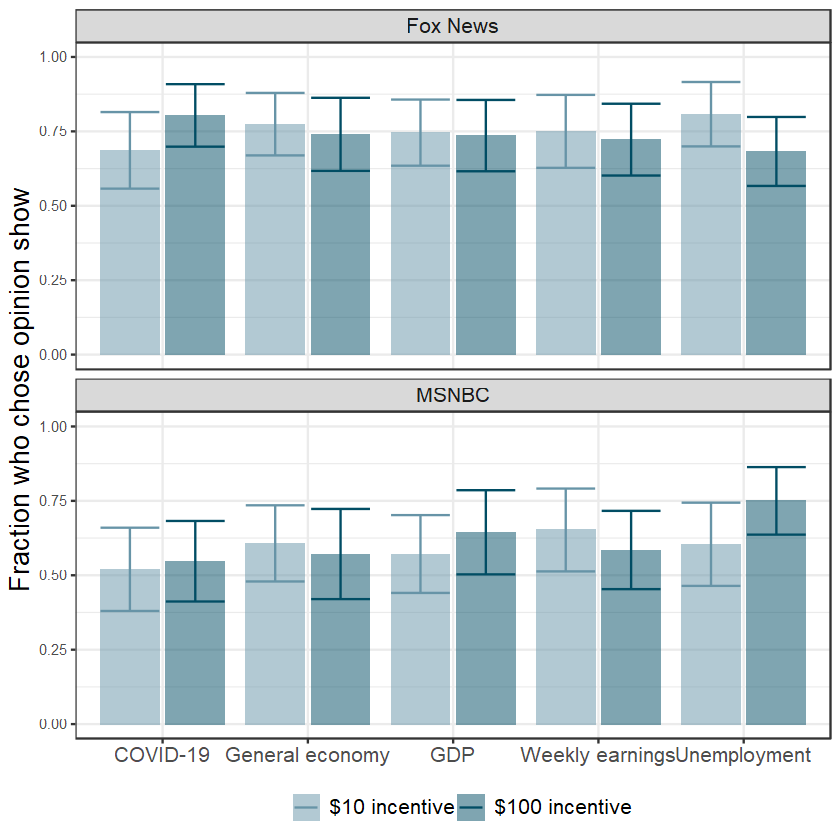

In [9]:
##########
# CREATE TRUST FIGURE AND TABLE
##########

library(tidyverse)
library(stringr)
library(stargazer)
library(haven)
library(extrafont)

tablenotes = rjson::fromJSON(file='../code/analysis/tablenotes.json')


# Read and prepare trust survey data
trust <- read_dta('../data/working/trust-survey.dta') %>% 
  mutate(highincentive=amount==100,
         outcome = factor(outcome, levels = c('covid', 'general','gdp','earnings','unemployment'),
                          labels = c('COVID-19','General economy','GDP','Weekly earnings','Unemployment')),
         incentive = ifelse(highincentive, '$100 incentive', '$10 incentive'))


# Trust figure
summary = trust %>% group_by(outcome, incentive, experiment) %>% 
  summarise(mean = mean(chose_opinion, na.rm=T),
            se = sd(chose_opinion, na.rm=T)/sqrt(n())) %>% 
  mutate(eh = mean+1.96*se, el = mean-1.96*se)

ggplot(summary, aes(x = outcome, y = mean, fill=incentive)) +
  geom_bar(stat='identity', position = position_dodge2(), alpha=0.5) +
  scale_fill_manual(values=c("#6794a7", "#014d64")) +
  geom_errorbar(aes(ymin = mean-1.96*se, ymax=mean+1.96*se, col = incentive), position = position_dodge2()) + 
  scale_color_manual(values=c("#6794a7", "#014d64")) +
  coord_cartesian(ylim=c(0, 1)) +
  facet_wrap(~experiment, ncol=1) +
  theme_bw() +
  theme(legend.position = 'bottom',
        legend.text=element_text(size=12),
        legend.title=element_text(size=12),
        axis.text.x = element_text(size=12),
        axis.title.y = element_text(size=16),
        strip.text.x = element_text(size=12),
        axis.title.x = element_blank(),
          text = element_text(family='sans')) +
  labs(fill = '', col= '') +
  xlab('Outcome') +
  ylab('Fraction who chose opinion show') 

ggsave('../output/figures/trust.png', height=7, width=7)


# Trust table

controls = 'age+gender+employ+hhi+race+hisp+educ'

create_panel = function(x, type = 'latex') {
  m1=lm(str_interp('chose_opinion~highincentive+${controls}'), data=x %>% filter(outcome=='COVID-19'))
  m2=lm(str_interp('chose_opinion~highincentive+${controls}'), data=x %>% filter(outcome=='General economy'))
  m3=lm(str_interp('chose_opinion~highincentive+${controls}'), data=x %>% filter(outcome=='GDP'))
  m4=lm(str_interp('chose_opinion~highincentive+${controls}'), data=x %>% filter(outcome=='Weekly earnings'))
  m5=lm(str_interp('chose_opinion~highincentive+${controls}'), data=x %>% filter(outcome=='Unemployment'))
  m6=lm(str_interp('chose_opinion~highincentive+${controls}'), data=x)
  
  means = map_dbl(c('COVID-19','General economy','GDP','Weekly earnings','Unemployment'), function(y) mean(x$chose_opinion[x$outcome==y], na.rm=T))
  means = c(means, mean(x$chose_opinion, na.rm=T)) %>% round(3) %>% format(nsmall=3) 
  
  capture.output(stargazer(list(m1, m2, m3, m4, m5, m6),
            type = type,
            column.labels = c('COVID-19','Economy','GDP','Earnings','Unemployment', 'Pooled'),
            keep = 'highincentive',
            dep.var.labels = 'Respondent chose opinion show',
            title = 'Trust in opinion shows',
            label = 't:trust-experiment',
            add.lines = list(c('Dep.~var.~mean', means)),
            covariate.labels = '\\$100 incentive'))
}

foxpanel = create_panel(trust %>% filter(experiment=='Fox News'))
msnbcpanel = create_panel(trust %>% filter(experiment=='MSNBC'))


table = c(
  foxpanel[4:6],
  '\\begin{threeparttable}',
  foxpanel[7:15],
  '\\multicolumn{7}{l}{\\textbf{Panel A}: Fox News viewers} \\\\',
  '\\midrule',
  foxpanel[c(16:18, 20:21)],
  '\\midrule',
  '\\multicolumn{7}{l}{\\textbf{Panel B}: MSNBC viewers} \\\\',
  '\\midrule',
  msnbcpanel[c(16:18, 20:21)],
  msnbcpanel[26],
  '\\midrule',
  msnbcpanel[28],
  '\\begin{tablenotes} \\small',
  paste0('\\item \\textit{Notes:} ', str_interp(tablenotes[['t:trust-experiment']])),
  '\\end{tablenotes} \\end{threeparttable} \\end{table}'
)

invisible(write_lines(table, '../output/tables/trust.tex'))
if (requireNamespace('IRdisplay', quietly = TRUE)) IRdisplay::display_html(paste(c(create_panel(trust %>% filter(experiment=='Fox News'), type='html'), '<br/>', create_panel(trust %>% filter(experiment=='MSNBC'), type='html')), collapse='\n'))

**Replication assessment**

The results of the paper are replicated. 


### *Diverging narratives about COVID-19*

Having provided evidence that people do rely on opinion shows for factual information, they turn to examine the consequences of that behavior in a high-stakes setting. To do so, they start by identifying the existence and timing of diverging narratives from opinion shows during the onset of the COVID-19 pandemic. 

They examine the two most popular opinion programs in the US: Hannity and Tucker Carlson Tonight. These shows are aired back-to-back on the same network (Fox News) and had similar content prior to January 2020; indeed, they show using natural language processing techniques that both in their selection of topics and the way they covered these topics, these shows were more similar than almost any other pair of primetime shows across Fox News and MSNBC. 

However, they document that the programs differed sharply along both margins in their reporting about COVID-19.

#### Figure 2: Show content validation ####

`summarise()` has grouped output by 'show'. You can override using the
`.groups` argument.
Warning message:
"Removed 18 rows containing missing values or values outside the scale range
(`geom_line()`)."
`summarise()` has grouped output by 'show'. You can override using the
`.groups` argument.
Warning message:
"Removed 18 rows containing missing values or values outside the scale range
(`geom_line()`)."


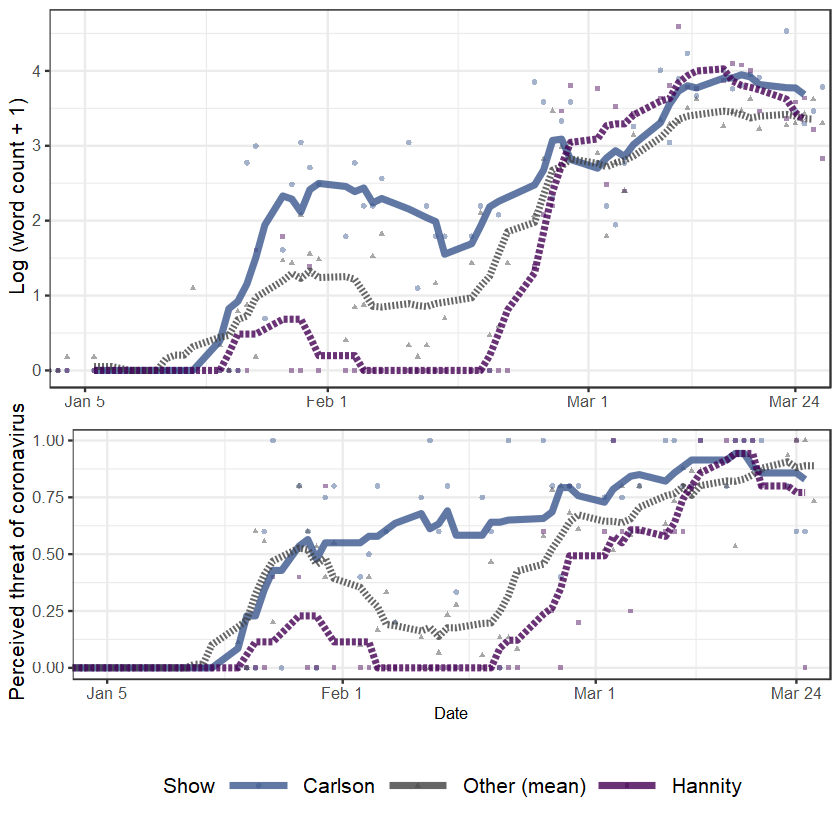

In [5]:
##########
# CREATE FOX WORD COUNT AND SERIOUSNESS FIGURES
##########

library(tidyverse)
library(haven)
library(zoo)
library(lubridate)
library(extrafont)
library(gridExtra)

# Fox word count figure
counts = read_dta('../data/working/transcript-word-counts.dta') %>%
  filter(network=='Fox News') %>%
  mutate(show = ifelse(show %in% c('The Five','The Ingraham Angle','The Story with Martha MacCallum', 
                                   'Special Report with Bret Baier', 'Fox News at Night'), 
                       'Other (mean)', show),
         show = dplyr::recode(show, 'Tucker Carlson'='Carlson','Sean Hannity'='Hannity')) %>%
  group_by(show, elapdate) %>%
  summarise(term_count = mean(term_count)) %>%
  ungroup() %>%
  mutate(show = factor(show, levels=c('Carlson','Other (mean)','Hannity'))) %>%
  group_by(show) %>%
  mutate(count_rolling=rollapply(log(1+term_count),7,mean,align='center',fill=NA))

plot_word_count = ggplot(counts, aes(x=elapdate, col = show)) + 
  geom_point(aes(y = log(term_count+1), shape=show), size=1, alpha=0.45) +
  geom_line(aes(y=count_rolling, linetype=show), size=1.5, alpha=0.8) +
  labs(col = 'Show', shape='Show') +
  guides(linetype=F, size=F) +
  ylab('Log (word count + 1)') +
  theme_bw() +
  theme(legend.position = 'none',
        axis.text = element_text(size=10),
        axis.title.y = element_text(size=12),
        axis.title.x = element_blank(),
        text = element_text(family='LM Roman 10')) +
  coord_cartesian(xlim=c(ymd('2020-01-05'), ymd('2020-03-24'))) +
  scale_x_date(
    breaks = ymd(c('2020-01-05', '2020-02-01', '2020-03-01', '2020-03-24')),
    labels = c('Jan 5', 'Feb 1', 'Mar 1', 'Mar 24')
  ) +
  scale_color_manual(values=c('#39568CFF', '#404040','#440154FF'))

#ggsave('../output/figures/fox-word-count.png', plot_word_count, width=6, height=2.85, units='in')

# Fox seriousness figure
seriousness = read_dta('../data/working/show-seriousness.dta') %>% 
  filter(show!='The Ingraham Angle', show!='The Five') %>%
  arrange(elapdate) %>%
  mutate(show = case_when(
    show=='Tucker Carlson' ~ 'Carlson',
    show=='Sean Hannity' ~ 'Hannity',
    show != 'Tucker Carlson' & show != 'Sean Hannity' ~ 'Other (mean)'
  )) %>%
  group_by(show, elapdate) %>%
  summarise(coronavirus_serious = mean(coronavirus_serious)) %>%
  mutate(serious_rolling=rollapply(coronavirus_serious,7,mean,align='center',fill=NA)) %>%
  ungroup() %>%
  mutate(
    serious_rolling = ifelse(elapdate<ymd('2020-01-15'), 0, serious_rolling)) %>%
  filter(!is.na(serious_rolling)) %>%
  mutate(show = factor(show, levels=c('Carlson','Other (mean)','Hannity'))) 

plot_seriousness = ggplot(seriousness, aes(x = elapdate, y = serious_rolling, col = show, shape=show, linetype=show)) + 
  geom_point(aes(y = coronavirus_serious), size=1, alpha=0.45) +
  geom_line(size=1.5, alpha=0.8) +
  guides(linetype=F, size=F) +
  theme(legend.position = 'bottom') +
  labs(col='Show', shape='Show') +
  xlab('Date') +
  ylab('Perceived threat of coronavirus') +
  theme_bw() +
  theme(legend.position = 'bottom',
        legend.text=element_text(size=12),
        legend.title=element_text(size=12),
        axis.text = element_text(size=10),
        axis.title.y = element_text(size=12),
        axis.title.x = element_text(size=10),
        text = element_text(family='LM Roman 10'),
        legend.key.size = unit(3, 'line')) +
  coord_cartesian(xlim=c(ymd('2020-01-05'), ymd('2020-03-24'))) +
  scale_x_date(
    breaks = ymd(c('2020-01-05', '2020-02-01', '2020-03-01', '2020-03-24')),
    labels = c('Jan 5', 'Feb 1', 'Mar 1', 'Mar 24')
  ) +
  scale_color_manual(values=c('#39568CFF', '#404040','#440154FF'))

# Render both inline as a single output so both are visible
gridExtra::grid.arrange(plot_word_count, plot_seriousness, ncol = 1)

# Optional save
#ggsave('../output/figures/fox-seriousness.png', plot_seriousness, width=6, height=3.75, units='in')

**Replication assessment**

The results of the paper are replicated. 

### *Timing of behavioural adjustment*

Having established that people relied on these two opinion programs to inform themselves about the ongoing pandemic and that the two shows held a diverging narratives over factual information about it, they proceed with examining the correlation between viewership of different news shows and the timing of behavioural change.

To capture more subtle behavioural changes that may have occurred in February and March, and to shed light on which types of behavioural change were most common, they fielded a survey on 3 April 2020. Their survey targeted a representative sample of approximately 1,500 Republicans aged 55 or older both because this population is more likely to watch Fox News and because the elderly are at increased risk from COVID-19.

They estimate the following specification:

$$
\text{TimingChange}_i = \alpha_0 + \beta S_i + \Pi X_i + \varepsilon_i
$$

where:

- $\mathrm{TimingChange}_i$ is the number of days after 1 February 2020 on which respondent $i$ reports having significantly changed any behavior in response to COVID-19,
- $S_i$ is a vector of indicators for whether respondent $i$ occasionally or regularly watches each of the seven shows,
- $X_i$ is a vector of demographic controls.

In [ ]:
##########
# CREATE BEHAVIOR FIGURES AND TABLES
# (quiet output, no note blocks)
##########

library(tidyverse)
library(stargazer)
library(lfe)
library(haven)
library(lubridate)
library(multcomp)
library(broom)
library(extrafont)

# Keep optional packages silent
has_starpolishr <- requireNamespace("starpolishr", quietly = TRUE)

tablenotes = rjson::fromJSON(file='../code/analysis/tablenotes.json')

survey = read_dta('../data/working/behavior-survey.dta') %>% 
  filter(foxviewer==1) %>%
  mutate(watch_other = watch_ingraham | watch_thefive | watch_story | watch_otherfoxshow) %>%
  mutate(stations_4_text = tolower(stations_4_text),
         broadcast = str_detect(stations_4_text, 'nbc|cbs|abc|bbc|local|broadcast'))

controls = 'age + male + retired + fulltime + hhi + whitenohisp + educ'
watch_other_shows = 'cnnviewer+msnbcviewer'

get_hannity_carlson_p_value = function(model) {
  ftest = summary(glht(model, 'watch_hannity-watch_carlson=0'))
  p = ftest$test$pvalues[1]
  if (p<0.001) {
    return('$<0.001$')
  } else{
    p = round(p, 3)
    return(sprintf("%.3f", p))
  }
}

# Behavior table
intensive_margin = function(survey) {
  survey$change_date[survey$change_by_survey_date==0] = max(survey$change_date, na.rm = TRUE)
  m1 = felm(as.formula(str_interp('change_date~watch_hannity+watch_carlson+watch_other+${watch_other_shows}+${controls}')), data=survey)
  m2 = felm(as.formula(str_interp('change_before_mar1~watch_hannity+watch_carlson+watch_other+${controls}+${watch_other_shows}')), data=survey)
  m3 = felm(as.formula(str_interp('change_before_mar15~watch_hannity+watch_carlson+watch_other+${controls}+${watch_other_shows}')), data=survey)
  m4 = felm(as.formula(str_interp('change_before_apr1~watch_hannity+watch_carlson+watch_other+${controls}+${watch_other_shows}')), data=survey)
  
  models = list(m1, m2, m3, m4)
  means = c(mean(survey$change_date, na.rm=TRUE), 
            mean(survey$change_before_mar1, na.rm=TRUE), 
            mean(survey$change_before_mar15, na.rm=TRUE), 
            mean(survey$change_before_apr1, na.rm=TRUE)) %>% round(3) %>% sprintf("%.3f", .) %>%
    paste(collapse='&')
  
  out = capture.output(stargazer(
    models,
    omit='age|male|retired|fulltime|hhi|white|educ|watch_ingraham|watch_thefive|watch_story|cnn|msnbc|Constant|watch_other',
    covariate.labels = c('Watches Hannity', 'Watches Carlson'),
    keep.stat = c('rsq', 'n'), 
    title = str_interp("Correlation between show viewership and timing of behavior change"),
    label = str_interp('t:survey'),
    add.lines = list(
      c('Demographic controls', rep(c('Yes'), 4)),
      c('Other viewership controls', rep(c('Yes'), 4))
    ),
    notes = '',
    notes.append = FALSE
  ))
  
  out = c(out[4:10], 
          ' & --- & \\multicolumn{3}{c}{Changed before...} \\\\',
          '\\cmidrule(rr){2-2} \\cmidrule(rr){3-5}',
          '& Change day & March 1 & March 15 & April 1 \\\\', 
          '\\cmidrule(rr){2-5}', 
          out[12:20],
          paste0('p-value (Hannity=Carlson) &', paste(map_chr(models, get_hannity_carlson_p_value), collapse=' & '), '\\\\'),
          '\\addlinespace',
          paste0('DV mean &', means, '\\\\'),
          '\\addlinespace',
          out[24:length(out)])
  
  # remove any leftover stargazer note lines
  out = out[!grepl('\\\\textit\\{Note:|\\^\\{\\*\\}', out)]
  writeLines(out, '../output/tables/behavior.tex')
  out = out[!grepl('controls|watch_other_shows', out)]
  writeLines(out, '../output/tables/behavior.tex')
  if (requireNamespace('IRdisplay', quietly = TRUE)) {
    html_out = capture.output(stargazer(
      models,
      type = 'html',
      omit='age|male|retired|fulltime|hhi|white|educ|watch_ingraham|watch_thefive|watch_story|cnn|msnbc|Constant|watch_other',
      covariate.labels = c('Watches Hannity', 'Watches Carlson'),
      column.labels = c('Change day', 'March 1', 'March 15', 'April 1'),
      dep.var.labels.include = FALSE,
      keep.stat = c('rsq', 'n'),
      title = 'Correlation between show viewership and timing of behavior change',
      add.lines = list(
        c('Demographic controls', rep(c('Yes'), 4)),
        c('Other viewership controls', rep(c('Yes'), 4))
      ),
      notes = '',
      notes.append = FALSE
    ))
    html_out = html_out[!grepl('<em>Note:</em>', html_out, fixed = TRUE)]
    IRdisplay::display_html(paste(html_out, collapse='\n'))
  }
}

intensive_margin(survey)


# Density figure
make_density_figure = function(survey) {
  survey$change_date[survey$change_by_survey_date==0] = max(survey$change_date, na.rm = TRUE)
  
  carlsonhannity = survey %>% 
    filter(watch_carlson==1 & watch_hannity!=1) %>%
    mutate(show='Carlson') %>%
    bind_rows(survey %>% filter(watch_hannity==1 & watch_carlson!=1) %>% mutate(show='Hannity')) %>%
    bind_rows(survey %>% filter(watch_other==1) %>% mutate(show='Other')) %>%
    mutate(date = ymd('2020-01-31')+days(change_date)) %>%
    mutate(show=factor(show, levels=c('Carlson','Other','Hannity')))
    
  plot1 = ggplot(carlsonhannity, aes(x = date, fill=show)) + 
      geom_density(alpha=0.8, col=NA) +
      scale_fill_manual(values = c('Carlson' = '#39568CFF', 'Other' = '#666666', 'Hannity' = '#440154FF')) +
      labs(fill='Show viewership') +
      xlab('Date of behavior change') +
      ylab('Density') +
      facet_wrap(~show, dir='v') +
      theme_bw() +
      guides(fill=FALSE) +
      theme(legend.position = 'bottom',
            axis.text.x = element_text(size=12),
            axis.title.y = element_text(size=16),
            strip.text.x = element_text(size=12),
            axis.title.x = element_blank(),
            text = element_text(family='LM Roman 10')) +
      geom_vline(data=filter(carlsonhannity, show=="Carlson"), aes(xintercept=mean(carlsonhannity$date[carlsonhannity$show=='Carlson'])), linetype='dashed') +
      geom_vline(data=filter(carlsonhannity, show=="Other"), aes(xintercept=mean(carlsonhannity$date[carlsonhannity$show=='Other'])), linetype='dashed') +
      geom_vline(data=filter(carlsonhannity, show=="Hannity"), aes(xintercept=mean(carlsonhannity$date[carlsonhannity$show=='Hannity'])), linetype='dashed') +
      scale_x_date(
        breaks = ymd(c('2020-02-01', '2020-03-01', '2020-04-01')),
        labels = c('Feb 1', 'Mar 1', 'Apr 1')
      )
  
  print(plot1)
  ggsave('../output/figures/behavior-density.png', plot = plot1, height=5, width=8)
}

make_density_figure(survey)

# Coef plot
make_daily_figure = function(survey) {
  df = tibble(elapdate=seq(ymd('2020-02-01'), ymd('2020-04-03'), by = '1 day'))
  
  estimate_model = function(x) {
    survey$outcome = (I(survey$change_date<=as.numeric(x-ymd('2020-02-01'))) & survey$change_by_survey_date==1)
    model = lm(as.formula(str_interp('outcome ~ watch_hannity+watch_carlson+watch_other+${controls}+${watch_other_shows}')), data=survey) %>% tidy
    hannity_coef = model[model$term=='watch_hannity', 'estimate'] %>% as.numeric()
    hannity_se = model[model$term=='watch_hannity', 'std.error'] %>% as.numeric()
    carlson_coef = model[model$term=='watch_carlson', 'estimate'] %>% as.numeric()
    carlson_se = model[model$term=='watch_carlson', 'std.error'] %>% as.numeric()
    
    return(c(hannity_coef, hannity_se, carlson_coef, carlson_se))
  }
  
  df = df %>% mutate(model = map(elapdate, estimate_model),
                     hannity_coef = map_dbl(model, 1),
                     hannity_se = map_dbl(model, 2),
                     hannity_error_high = hannity_coef+1.96*hannity_se,
                     hannity_error_low = hannity_coef-1.96*hannity_se,
                     carlson_coef = map_dbl(model, 3),
                     carlson_se = map_dbl(model, 4),
                     carlson_error_high = carlson_coef+1.96*carlson_se,
                     carlson_error_low = carlson_coef-1.96*carlson_se) %>%
    dplyr::select(-model)
  
  hannity = df %>% dplyr::select(elapdate:hannity_error_low) %>% mutate(type = 'Watch Hannity')
  names(hannity) = c('elapdate','coef','se','error_high','error_low', 'type')
  carlson = df %>% dplyr::select(elapdate, carlson_coef:carlson_error_low) %>% mutate(type = 'Watch Carlson')
  names(carlson) = c('elapdate','coef','se','error_high','error_low', 'type')
  df_to_plot = bind_rows(hannity, carlson) %>%
    mutate(type = factor(type, levels=c('Watch Carlson','Watch Hannity')))
  
  plot = ggplot(df_to_plot, aes(x = elapdate, y = coef)) + geom_point(aes(col=type, shape=type))  +
    geom_ribbon(aes(ymin=error_low, ymax=error_high, fill=type), alpha=0.2) +
    scale_shape_manual(values=c(15, 16)) +
    scale_fill_manual(values=c('#39568CFF', '#440154FF')) +
    scale_color_manual(values=c('#39568CFF', '#440154FF')) +
    scale_x_date(
      breaks = ymd(c('2020-02-01', '2020-02-15', '2020-03-01', '2020-03-15', '2020-04-01')),
      labels = c('Feb 01', 'Feb 15', 'Mar 01', 'Mar 15', 'Apr 01')
    ) +
    labs(fill='Show', col='Show', shape='Show') +
    theme_bw() +
    ylab('Coefficient estimate') +
    theme(legend.position = 'bottom',
          legend.text=element_text(size=12),
          legend.title=element_text(size=12),
          axis.text.x = element_text(size=12),
          axis.title.y = element_text(size=16),
          strip.text.x = element_text(size=12),
          axis.title.x = element_blank(),
          text = element_text(family='LM Roman 10'))
  
  print(plot)
}

make_daily_figure(survey)


# Viewership characteristics table
make_demographic_table = function(survey) {
  exc = survey %>% 
    filter(watch_carlson_no_hannity | watch_hannity_no_carlson) %>% 
    mutate(show = ifelse(watch_carlson_no_hannity, 'Tucker Carlson Tonight', 'Hannity'),
           hhi = case_when(
             str_detect(hhi, '100,') ~ 125000,
             str_detect(hhi, '15,') ~ 20000,
             str_detect(hhi, '150,') ~ 175000,
             str_detect(hhi, '25,') ~ 37500,
             str_detect(hhi, '74,') ~ 62500,
             str_detect(hhi, '99') ~ 87500,
             str_detect(hhi, 'Less') ~ 10000,
             str_detect(hhi, 'More') ~ 250000
           ),
           educ = case_when(
             str_detect(educ, 'Associate') ~ 14,
             str_detect(educ, 'Bachelor') ~ 16,
             str_detect(educ, 'Doctoral') ~ 22,
             str_detect(educ, 'High') ~ 12,
             str_detect(educ, 'Less') ~ 10,
             str_detect(educ, 'Master') ~ 18,
             str_detect(educ, 'Professional') ~ 19,
             str_detect(educ, 'Some college') ~ 14,
           )) %>% 
    dplyr::select(show, age, male, retired, fulltime, hhi, whitenohisp, educ, cnnviewer, msnbcviewer, broadcast) %>% 
    group_by(show) %>% 
    summarise(across(everything(), ~mean(.x, na.rm=TRUE))) %>% 
    rename(Age = age, `Years of education` = educ, `Household income (\\$)` = hhi,
           `White` = whitenohisp, `Works full time` = fulltime, `Retired` = retired, 
           Male = male, `Watches CNN` = cnnviewer, `Watches MSNBC` = msnbcviewer,
           `Watches broadcast news` = broadcast) %>% 
    t() %>% 
    as.data.frame() 
  exc$demo = rownames(exc)
  exc = exc[-1,c(3,2,1)]
  if (!("V1" %in% names(exc))){
    exc = exc %>% rename(V1 = "1", V2="2")
  }
  
  exc = exc %>% mutate(across(c(V1, V2), function(x) round(as.numeric(x), 2)))
  if (requireNamespace('IRdisplay', quietly = TRUE) && requireNamespace('knitr', quietly = TRUE)) {
    inline_exc = exc %>% dplyr::select(demo, V2, V1)
    names(inline_exc) = c('Demographic', 'Tucker Carlson Tonight', 'Hannity')
    IRdisplay::display_html(as.character(knitr::kable(inline_exc, format = 'html', row.names = FALSE)))
  }
  
  exc = exc %>% 
    unite(latex, demo:V1, sep=' & ') %>% 
    mutate(latex = paste0(latex, '\\\\'))
  
  table = c(
    '\\begin{table}[!htbp] \\centering',
    '\\caption{Demographics of Tucker Carlson Tonight vs. Hannity viewers}',
    '\\label{t:viewer-characteristics}',
    '\\begin{tabular}{@{}lll@{}}',
    '\\toprule',
    '\\textbf{Demographic} & \\textbf{\\emph{Tucker Carlson Tonight}} & \\textbf{\\emph{Hannity}} \\\\ \\midrule',
    exc$latex,
    '\\bottomrule',
    '\\end{tabular}',
    '\\end{table}'
  )
  
  write_lines(table, '../output/tables/behavior-characteristics.tex')

}
make_demographic_table(survey)

**Replication assessment**

The results of the paper are replicated. 

### *OLS estimates on health outcomes*

In this section they present OLS evidence on the effects of differential viewership of Hannity and Tucker Carlson Tonight on COVID-19 cases and deaths. 

To do so, they use the following data categories: TV viewership data, 2018 data on the local market share of each of the “Big Three” networks, data on county level characteristics, including local vote shares, educational attainment, incomes, and the demographic age structure

The estimate the following primary specification:

$$
Y_{mct} = \alpha_t + \beta_t D_{mc} + \Pi_t X_{mc} + \varepsilon_{mct}
$$

where:

- $Y_{mct}$ is the outcome (e.g., $\log(1+\text{cases})$ or $\log(1+\text{deaths})$) in media market $m$, county $c$, on day $t$,
- $D_{mc}$ is the standardized difference between viewership shares of *Hannity* and *Tucker Carlson Tonight*,
- $X_{mc}$ is a vector of county-level controls.


Identification is challenging as there are a lot of potential confounders. The OLS specification effectively exploits variation arising from differences in timing preferences and channel preferences:

$$
Y_{mct} = \alpha_t + \beta_t \left( s_{mc,H} \times f_{mc,H} - s_{mc,T} \times f_{mc,T} \right) + \Pi_t X_{mc} + \varepsilon_{mct}
$$

where:

- $s_{mc,h}$ is the share of households in media market $m$, county $c$, that watch any TV channel at time-slot $h$,
- $f_{mc,h}$ is the share of those households that, at that moment, tune in to Fox News at time-slot $h$.


#### Figure 4 & Table 3: Effect of differential viewership on COVID-19 outcomes ####

In [12]:
##########
# CREATE TIMESERIES FIGURES
##########

source('C:/Users/kater/Academics/Coursework/Causal_Inference_S26/opinions_replication_CI/code/analysis/load.R')
library(zoo)

timeseries_figure = function(typearg, misinfoarg=FALSE, version, cluster='geography', add_controls = '') {
  
  agg_deaths = make_coef_df('deaths', typearg, misinfo=misinfoarg, version=version, data, cluster=cluster, add_controls=add_controls) %>% 
    mutate(outcome='Deaths')
  
  agg_cases = make_coef_df('cases', typearg, misinfo=misinfoarg, version=version, data, cluster=cluster, add_controls=add_controls) %>% 
    mutate(outcome='Cases')
  
  agg = agg_deaths %>%
    bind_rows(agg_cases)
  
  plot = ggplot(agg, aes(x = elapdate, y = coef)) + 
    geom_point(aes(col = outcome, shape=outcome), fill='black', size=2) + 
    geom_ribbon(aes(ymin=error_low, ymax=error_high, fill=outcome), alpha=0.07, col=NA) +
    ylab(str_interp('${typearg} estimate')) +
    labs(fill='Outcome', col='Outcome', shape='Outcome') +
    theme_bw() +
    theme(legend.position = 'bottom',
          legend.text=element_text(size=12),
          legend.title=element_text(size=12),
          axis.text = element_text(size=10),
          axis.title.y = element_text(size=12),
          axis.title.x = element_blank(),
          text = element_text(family='LM Roman 10')) +
    scale_color_manual(values=c('#808080', '#DC143C')) +
    scale_fill_manual(values=c('#808080', '#DC143C')) +
    coord_cartesian(xlim=c(ymd('2020-02-24'),ymd("2020-04-15")))
  return (plot)
}

# Timeseries
timeseries_figure('OLS', misinfo=FALSE, version='V1') %>% ggsave(str_interp('../output/figures/OLS-timeseries.png'), ., width=6, height=4, units='in') 
timeseries_figure('2SLS', misinfo=FALSE, version='V1') %>% ggsave(str_interp('../output/figures/V1-timeseries.png'), ., width=6, height=4, units='in')

# Tiemseries with state clustering
timeseries_figure('2SLS', misinfo=FALSE, version='V1', cluster='state_fips') %>% ggsave(str_interp('../output/figures/V1-timeseries-state-clustering.png'), ., width=6, height=4, units='in') 
timeseries_figure('OLS', misinfo=FALSE, version='V1', cluster='state_fips') %>% ggsave(str_interp('../output/figures/OLS-timeseries-state-clustering.png'), ., width=6, height=4, units='in') 



# Leaveout figure
create_leaveout_figure = function(typearg, misinfoarg=FALSE, version) {
  
  aggs = list()
  
  for (lo in list(c(6, 25, 34, 36, 53), c(6), c(25), c(34), c(36), c(53), '1p', 'highest')) {
    if (is.character(lo) && identical(lo, '1p')) {
      to_keep = data %>% 
        filter(elapdate == '2020-04-15') %>% 
        filter(cases <= quantile(cases, 0.99, na.rm=T))
      filtered = data %>% filter(fipscode %in% to_keep$fipscode)
    } else if (is.character(lo) && identical(lo, 'highest')) {
      to_keep = data %>% 
        filter(elapdate == '2020-04-15') %>% 
        group_by(state_fips) %>%
        arrange(desc(cases)) %>% 
        filter(row_number()>1)
      filtered = data %>% filter(fipscode %in% to_keep$fipscode)
    } else {
      filtered = data %>% filter(!(state_fips %in% lo))
    }
    
    agg = make_coef_df('deaths', typearg, misinfo=misinfoarg, version=version, filtered, ci=1.96) %>% 
      mutate(outcome='Deaths') %>%
      bind_rows(make_coef_df('cases', typearg, misinfo=misinfoarg, version=version, filtered, ci=1.96) %>% 
                  mutate(outcome='Cases')) %>%
      mutate(lo = as.character(ifelse(length(lo)>1, paste(lo, collapse=' '), lo)))
    aggs[[length(aggs)+1]] = agg
  }

  agg = bind_rows(aggs) %>%
    mutate(
      leftout = case_when(
        lo == '6 25 34 36 53' ~ 'Leave out CA, MA, NJ, NY, WA',
        lo == '36' ~ 'Leave out NY',
        lo == '53' ~ 'Leave out WA',
        lo == '6'  ~ 'Leave out CA',
        lo == '34' ~ 'Leave out NJ',
        lo == '1p' ~ 'Leave out top 1%',
        lo == 'highest' ~ 'Leave out highest-case county in each state',
        lo == '25'  ~ 'Leave out MA'),
      leftout = factor(leftout, levels = c('Leave out CA', 
                                           'Leave out MA',
                                           'Leave out NJ', 
                                           'Leave out NY', 
                                           'Leave out WA',
                                           'Leave out CA, MA, NJ, NY, WA',
                                           'Leave out top 1%',
                                           'Leave out highest-case county in each state')))
  
  plot = ggplot(agg, aes(x = elapdate, y = coef)) + 
    geom_point(aes(col = outcome, shape = outcome), fill='black', size=2) +
    geom_ribbon(aes(ymin=error_low, ymax=error_high, fill=outcome), alpha=0.15, col=NA) +
    ylab(str_interp('${typearg} estimate')) +
    labs(fill='Outcome', col='Outcome', shape='Outcome') +
    theme_bw() +
    theme(legend.position = 'bottom',
          legend.text=element_text(size=14),
          legend.title=element_text(size=14),
          axis.text = element_text(size=12),
          axis.title.y = element_text(size=14),
          axis.title.x = element_blank(),
          strip.text.x = element_text(size=14),
          text = element_text(family='LM Roman 10')) +
    scale_color_manual(values=c('#808080', '#DC143C')) +
    scale_fill_manual(values=c('#808080', '#DC143C')) +
    coord_cartesian(xlim=c(ymd('2020-02-24'),ymd("2020-04-15")), ylim=c(-0.5, 1.1))
  return (plot)
}

(create_leaveout_figure('2SLS', misinfo=FALSE, version='V1') + facet_wrap(~leftout, ncol = 2)) %>%  
 ggsave(str_interp('../output/figures/V1-timeseries-leaveout.png'), ., width=7, height=8, units='in') 

(create_leaveout_figure('2SLS', misinfo=FALSE, version='V1') + facet_wrap(~leftout, ncol = 2)) %>%
  ggsave(str_interp('../output/figures/V1-timeseries-leaveout.png'), ., width=7, height=8.2, units='in') 


# Timeseries with unbalanced panel
unbalanced_panel_figure = function(typearg, version, threshold) {
  
  agg = make_coef_df('deaths', typearg, version=version, dataarg=data %>% filter(cases>=threshold), begin='2020-03-13') %>% 
    mutate(outcome='Deaths') %>%
    bind_rows(make_coef_df('cases', typearg, version=version, dataarg=data %>% filter(cases>=threshold), begin='2020-03-13') %>% 
                mutate(outcome='Cases'))
  plot = ggplot(agg, aes(x = elapdate, y = coef)) + 
    geom_point(aes(col = outcome, shape=outcome), fill='black', size=2) + 
    geom_ribbon(aes(ymin=error_low, ymax=error_high, fill=outcome), alpha=0.07, col=NA) +
    ylab(str_interp('${typearg} estimate')) +
    labs(fill='Outcome', col='Outcome', shape='Outcome') +
    theme_bw() +
    theme(legend.position = 'bottom',
          legend.text=element_text(size=12),
          legend.title=element_text(size=12),
          axis.text = element_text(size=10),
          axis.title.y = element_text(size=12),
          axis.title.x = element_blank(),
          text = element_text(family='LM Roman 10')) +
    scale_color_manual(values=c('#808080', '#DC143C')) +
    scale_fill_manual(values=c('#808080', '#DC143C')) +
    coord_cartesian(xlim=c(ymd('2020-03-13'),ymd("2020-04-15")), ylim=c(-0.5, 1.1))
  
  return (plot)
}

unbalanced_panel_figure('2SLS', version='V1', threshold=1) %>% ggsave(str_interp('../output/figures/V1-timeseries-unbalanced.png'), ., width=6, height=4, units='in') 



Package 'starpolishr' not available; using built-in star_notes_tex fallback.

Warning message:
"There were 253 warnings in `mutate()`.
The first warning was:
ℹ In argument: `model = map(data, estimate_model)`.
ℹ In group 4: `elapdate = 2020-03-04`.
Caused by warning in `chol.default()`:
! the matrix is either rank-deficient or not positive definite
ℹ Run `dplyr::last_dplyr_warnings()` to see the 252 remaining warnings."
Warning message:
"There were 262 warnings in `mutate()`.
The first warning was:
ℹ In argument: `model = map(data, estimate_model)`.
ℹ In group 1: `elapdate = 2020-02-24`.
Caused by warning in `chol.default()`:
! the matrix is either rank-deficient or not positive definite
ℹ Run `dplyr::last_dplyr_warnings()` to see the 261 remaining warnings."
Warning message:
"There were 256 warnings in `mutate()`.
The first warning was:
ℹ In argument: `model = map(data, estimate_model)`.
ℹ In group 1: `elapdate = 2020-03-01`.
Caused by warning in `chol.default()`:
! the matrix is eith

: 

**Replication assessment**

I did not manage to replicate this result. The cell was running for 816 min, so I had to interrupt it. I will return to investigate this, time permitted. 

#### DiD Robustness: Hannity vs Carlson Viewers

This cell re-estimates behavior-change dynamics using a Difference-in-Differences design with an early cutoff aligned to narrative divergence.

- Treatment group: Hannity-only viewers
- Control group: Carlson-only viewers
- Post period starts on 2020-01-27
- Outcome is whether a respondent had changed behavior by each day

The cell is independent: it loads its own packages and data, constructs the daily panel, estimates the DiD model, and plots cumulative behavior change by group over time.

The variable 'post' has been removed because of collinearity (see $collin.var).

Warning message:
"The VCOV matrix is not positive semi-definite and was 'fixed' (see ?vcov)."


OLS estimation, Dep. Var.: changed_by_day
Observations: 13,800
Fixed-effects: day: 75
Standard-errors: Clustered (id) 
                      Estimate Std. Error   t value  Pr(>|t|)    
treat_hannity       0.00000000 0.00000100  0.000000 1.0000000    
treat_hannity:post -0.09461988 0.03334157 -2.837895 0.0050539 ** 
... 1 variable was removed because of collinearity (post)
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 0.303978     Adj. R2: 0.553943
                 Within R2: 0.018259


Term,Estimate,Std. Error,95% CI,p-value
Hannity x Post (DiD),-0.0946,0.0333,"[-0.1604, -0.0288]",0.00505


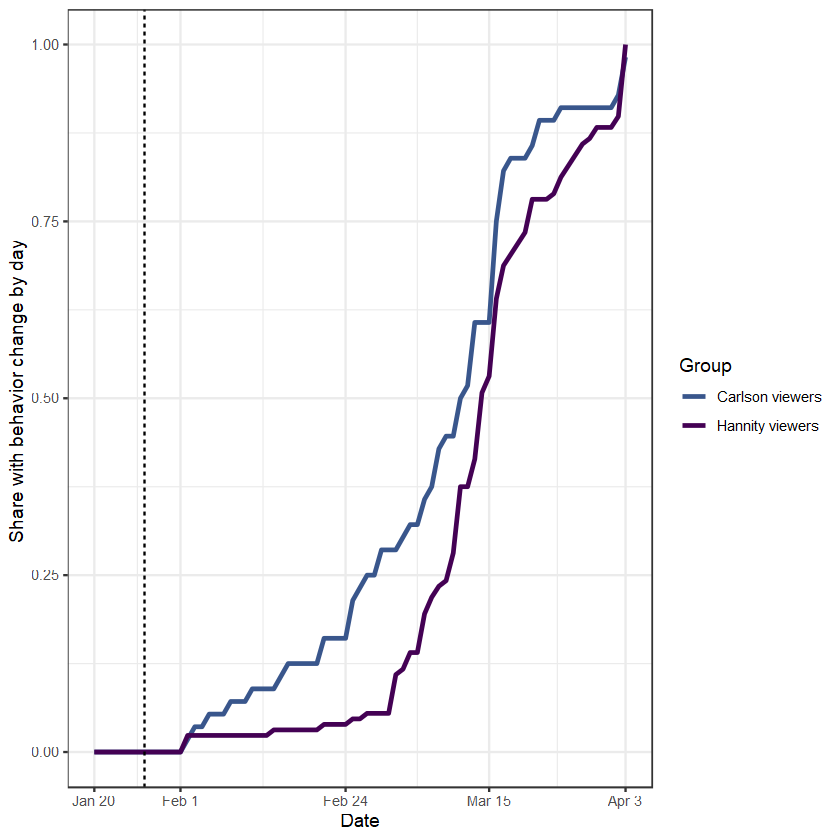

In [3]:
##########
# DiD: Hannity vs Carlson viewers 
##########

library(tidyverse)
library(haven)
library(lubridate)
library(fixest)

# Load data independently for this cell
survey_did <- read_dta('../data/working/behavior-survey.dta') %>%
  filter(foxviewer == 1) %>%
  mutate(id = row_number()) %>%
  filter((watch_hannity == 1 & watch_carlson == 0) | (watch_hannity == 0 & watch_carlson == 1)) %>%
  mutate(
    treat_hannity = if_else(watch_hannity == 1, 1L, 0L),
    event_date = ymd('2020-02-01') + days(change_date),
    event_date = if_else(change_by_survey_date == 1, event_date, ymd('2020-04-03'))
  )

# Early cutoff tied to narrative divergence.
did_cutoff <- ymd('2020-01-27')
panel_start <- ymd('2020-01-20')
panel_end <- ymd('2020-04-03')

did_panel <- tidyr::expand_grid(
  id = survey_did$id,
  day = seq(panel_start, panel_end, by = '1 day')
) %>%
  left_join(survey_did %>% dplyr::select(id, treat_hannity, event_date), by = 'id') %>%
  mutate(
    post = as.integer(day >= did_cutoff),
    changed_by_day = as.integer(day >= event_date)
  )

# Two-way design with day fixed effects; interaction is the DiD estimate
did_model <- feols(changed_by_day ~ treat_hannity * post | day, cluster = ~id, data = did_panel)
print(summary(did_model))

if (requireNamespace('IRdisplay', quietly = TRUE) && requireNamespace('broom', quietly = TRUE) && requireNamespace('knitr', quietly = TRUE)) {
  did_tidy_all <- broom::tidy(did_model, conf.int = TRUE)
  did_tidy <- did_tidy_all %>%
    dplyr::filter(term == 'treat_hannity:post') %>%
    dplyr::transmute(
      Term = 'Hannity x Post (DiD)',
      Estimate = round(estimate, 4),
      `Std. Error` = round(std.error, 4),
      `95% CI` = paste0('[', round(conf.low, 4), ', ', round(conf.high, 4), ']'),
      `p-value` = signif(p.value, 3)
    )

  if (nrow(did_tidy) == 0) {
    did_tidy <- tibble(
      Term = 'Hannity x Post (DiD)',
      Estimate = NA_real_,
      `Std. Error` = NA_real_,
      `95% CI` = 'Not estimable (collinearity)',
      `p-value` = NA_real_
    )
  }

  IRdisplay::display_html(as.character(knitr::kable(did_tidy, format = 'html', row.names = FALSE)))
}

plot_did <- did_panel %>%
  group_by(day, treat_hannity) %>%
  summarise(share_changed = mean(changed_by_day, na.rm = TRUE), .groups = 'drop') %>%
  mutate(group = if_else(treat_hannity == 1, 'Hannity viewers', 'Carlson viewers')) %>%
  ggplot(aes(x = day, y = share_changed, color = group)) +
  geom_line(size = 1) +
  geom_vline(xintercept = did_cutoff, linetype = 'dashed') +
  scale_color_manual(values = c('Carlson viewers' = '#39568CFF', 'Hannity viewers' = '#440154FF')) +
  scale_x_date(
    breaks = ymd(c('2020-01-20', '2020-02-01', '2020-02-24', '2020-03-15', '2020-04-03')),
    labels = c('Jan 20', 'Feb 1', 'Feb 24', 'Mar 15', 'Apr 3')
  ) +
  labs(
    x = 'Date',
    y = 'Share with behavior change by day',
    color = 'Group'
  ) +
  theme_bw()

print(plot_did)

#### Interpretation of the DiD Robustness Check

- The treatment cutoff is set to **2020-01-27** (late January), matching the period when show narratives begin to diverge.
- The panel starts at **2020-01-20**, so the model has a genuine pre-period before treatment starts.
- In the latest run, the DiD interaction (`Hannity x Post`) is about **-0.0946** (p-value about **0.005**), implying that after the cutoff, Hannity viewers are around **9.5 percentage points less likely** than Carlson viewers to have changed behavior by a given day, relative to the pre-period gap.
- With day fixed effects, the main `post` dummy is dropped for collinearity. But, the key identifying parameter is the interaction term (`Hannity x Post`), which remains estimable.

This robustness check supports the same qualitative conclusion: behavior adjustment appears later among Hannity viewers than among Carlson viewers once narratives diverge.